# Multi-linear regression: when does a second predictor help?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/minimum_corr_for_added_value.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-22*

## Learning objectives

- Derive (and verify by experiment) the **minimum useful correlation** that a second predictor `x2` must have with `y` for it to add real value beyond `x1` in a multi-linear regression setting.
- See **overfitting** in action by fitting `y` to dozens of *random* predictors and watching `R²` rise.
- Use the **adjusted `R²`** as a penalty against extra predictors, and put confidence bounds on it via random-data Monte Carlo.

---


In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model, metrics

mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150

np.random.seed(300)

## Build the toy data

Two predictors `x1` and `x2` and a target `y`.

- `x1`: independent standard-normal noise.
- `x2`: AR(1)-style mixture, correlated with `x1` at lag-0 by parameter `a = 0.8`.
- `y`: a small dose of `x1`, a tiny dose of `x2`, and a lot of noise.


In [2]:
N = 100

x1 = np.random.normal(0.0, 1.0, size=N)

a = 0.8
b = np.sqrt(1.0 - a**2)
x2 = a * x1 + b * np.random.normal(size=N)

a_y = 0.3
b_y = np.sqrt(1.0 - a_y**2)
y = a_y * x1 + 0.05 * x2 + b_y * np.random.normal(size=N)

## Check the correlations


In [3]:
c12 = np.corrcoef(x1, x2)[0, 1]
c1y = np.corrcoef(x1, y)[0, 1]
c2y = np.corrcoef(x2, y)[0, 1]
print(f"corr(x1, x2) = {c12:.3f}")
print(f"corr(x1, y)  = {c1y:.3f}")
print(f"corr(x2, y)  = {c2y:.3f}")

corr(x1, x2) = 0.828
corr(x1, y)  = 0.426
corr(x2, y)  = 0.350


## Theory: the minimum useful correlation

For `x2` to add information about `y` beyond what `x1` already provides, its correlation with `y` must exceed what `x1` would induce through their shared correlation `c12`. The threshold is

$$|c_{2y}|_{\text{min useful}} \;=\; |c_{1y}\,c_{12}|.$$


In [4]:
min_useful = np.abs(c1y * c12)
print(f"minimum useful |corr(x2, y)| = {min_useful:.3f}")

minimum useful |corr(x2, y)| = 0.353


When `|c2y|` is below this threshold, the variance-explained formula

$$R^2 \;=\; \frac{c_{1y}^2 + c_{2y}^2 - 2\,c_{1y}\,c_{2y}\,c_{12}}{1 - c_{12}^2}$$

returns essentially the same value as `c1y**2` alone — `x2` brings no new information.


In [5]:
r2_x1_only = c1y**2
r2_x1_x2 = (c1y**2 + c2y**2 - 2 * c1y * c2y * c12) / (1 - c12**2)
print(f"theory: var(y) explained by x1       = {r2_x1_only:.3f}")
print(f"theory: var(y) explained by x1 & x2  = {r2_x1_x2:.3f}")

theory: var(y) explained by x1       = 0.181
theory: var(y) explained by x1 & x2  = 0.181


## Confirm by actually fitting

`sklearn.linear_model.LinearRegression` does the OLS multivariate fit. We expect the two-predictor fit to give the same `R²` as theory.


In [6]:
def fit_r2(predictors, target):
    X = np.atleast_2d(predictors).T if predictors.ndim == 1 else predictors
    regr = linear_model.LinearRegression()
    regr.fit(X, target)
    return metrics.r2_score(target, regr.predict(X))


R2_x1 = fit_r2(x1, y)
R2_x12 = fit_r2(np.column_stack([x1, x2]), y)
print(f"R^2 fit with x1       = {R2_x1:.5f}")
print(f"R^2 fit with x1 & x2  = {R2_x12:.5f}")

R^2 fit with x1       = 0.18142
R^2 fit with x1 & x2  = 0.18144


The two `R²` values are nearly identical. The tiny gap with `x2` included is **not** real signal — it's the inevitable rise in `R²` you get from adding any predictor at all, even one with no information. Which leads us to overfitting.

## Overfitting: 40 random predictors

Drop all pretense of meaning. Generate `Y` and 40 predictors `X` independently from `N(0, 1)`, and add the predictors one at a time. `R²` should rise monotonically toward 1 — purely by chance.


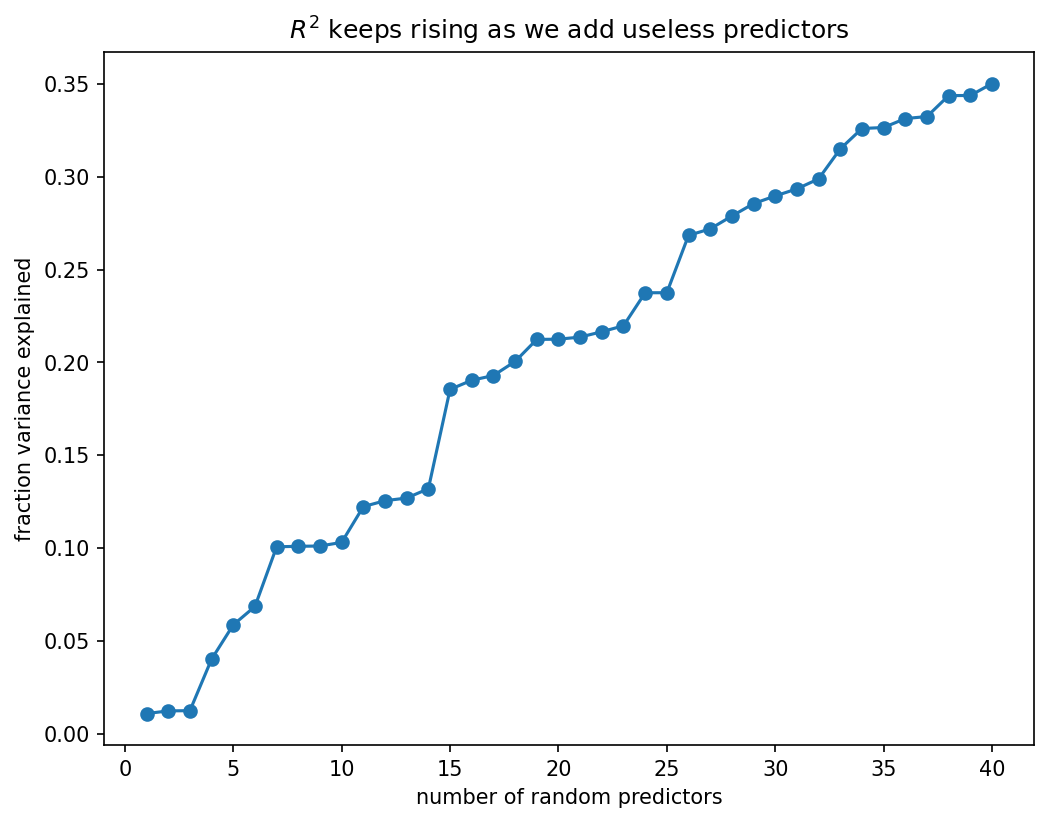

In [7]:
X = np.random.normal(0.0, 1.0, size=(N, 40))
Y = np.random.normal(0.0, 1.0, size=N)

rval = []
for k in range(X.shape[1]):
    rval.append(fit_r2(X[:, : k + 1], Y))

plt.figure(figsize=(8, 6))
plt.plot(np.arange(1, X.shape[1] + 1), rval, "o-")
plt.xlabel("number of random predictors")
plt.ylabel("fraction variance explained")
plt.title("$R^2$ keeps rising as we add useless predictors")
plt.show()

With 40 predictors and 100 samples, `R²` climbs toward 1 even though the predictors carry no real information.

## Adjusted `R²`

The adjusted `R²` penalizes extra predictors:

$$R^2_\text{adj} \;=\; 1 - (1 - R^2)\,\frac{n - 1}{n - p - 1},$$

where `n` is the sample size and `p` the number of predictors. It only rises when a new predictor improves the fit more than expected by chance.


In [8]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [9]:
print("x1 only:")
print(f"  R^2 = {R2_x1:.3f}, adjusted R^2 = {adjusted_r2(R2_x1, N, 1):.3f}")
print("x1 and x2:")
print(f"  R^2 = {R2_x12:.3f}, adjusted R^2 = {adjusted_r2(R2_x12, N, 2):.3f}")

x1 only:
  R^2 = 0.181, adjusted R^2 = 0.173
x1 and x2:
  R^2 = 0.181, adjusted R^2 = 0.165


Adding the not-really-helpful `x2` *lowered* the adjusted `R²`. Good — that's the penalty doing its job.

Now plot adjusted `R²` for the 40-random-predictors experiment alongside raw `R²`.


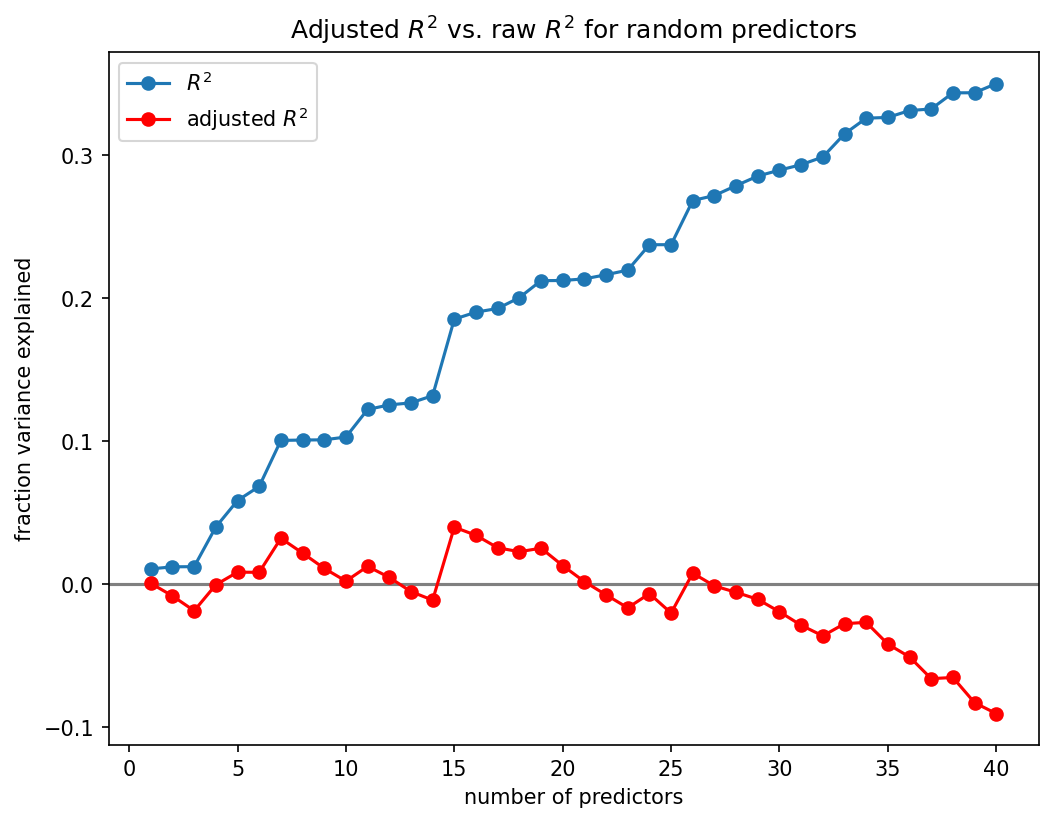

In [10]:
p_vec = np.arange(1, X.shape[1] + 1)
adj_r2 = adjusted_r2(np.asarray(rval), N, p_vec)

plt.figure(figsize=(8, 6))
plt.axhline(y=0, color="gray")
plt.plot(p_vec, rval, "o-", label="$R^2$")
plt.plot(p_vec, adj_r2, "o-", color="red", label="adjusted $R^2$")
plt.xlabel("number of predictors")
plt.ylabel("fraction variance explained")
plt.title("Adjusted $R^2$ vs. raw $R^2$ for random predictors")
plt.legend()
plt.show()

## Significance of adjusted `R²`

Even adjusted `R²` has random spread. Run the random-data experiment many times to estimate the 95% confidence band.


In [11]:
n_repeats = 500
n_max = 40

rVec = np.empty((n_max, n_repeats))
for nvar in range(1, n_max + 1):
    raw = []
    for _ in range(n_repeats):
        Xr = np.random.normal(0.0, 1.0, size=(N, nvar))
        Yr = np.random.normal(0.0, 1.0, size=N)
        raw.append(fit_r2(Xr, Yr))
    rVec[nvar - 1, :] = adjusted_r2(np.asarray(raw), N, nvar)

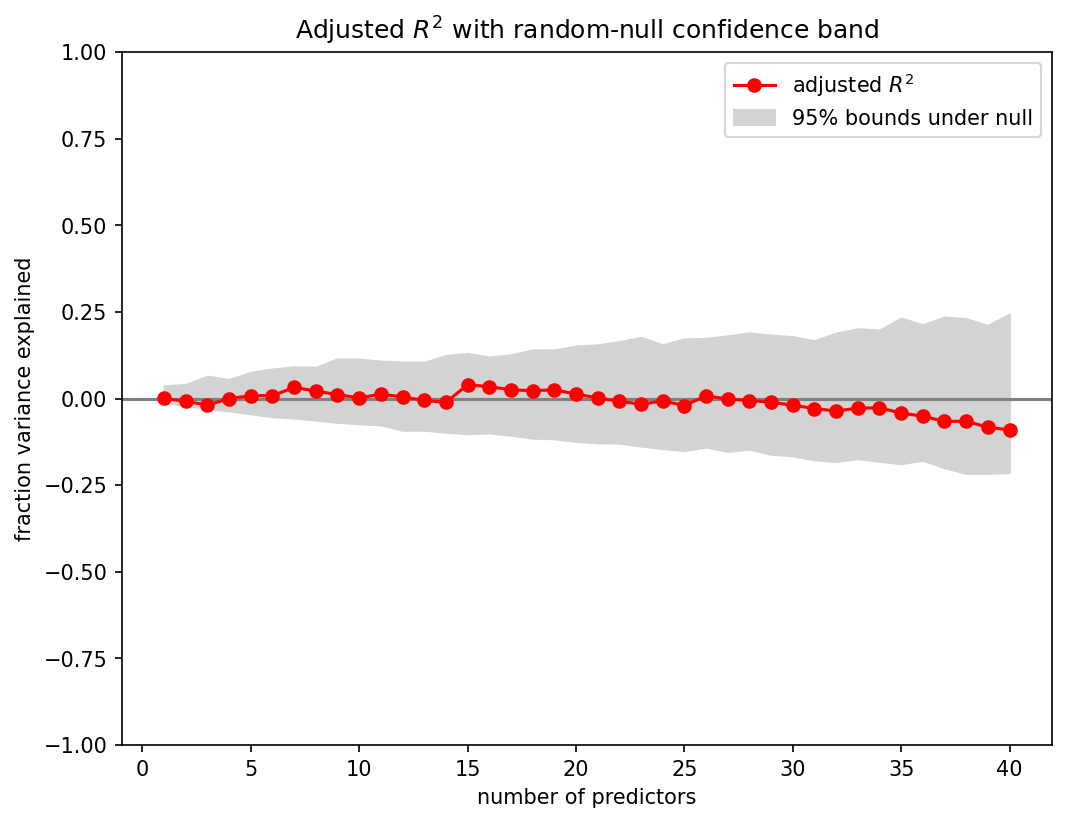

In [12]:
pTop = np.percentile(rVec, 97.5, axis=1)
pBot = np.percentile(rVec, 2.5, axis=1)

plt.figure(figsize=(8, 6))
plt.axhline(y=0, color="gray")
plt.plot(p_vec, adj_r2, "o-", color="red", label="adjusted $R^2$")
plt.fill_between(
    np.arange(1, n_max + 1),
    pBot,
    pTop,
    color="lightgray",
    label="95% bounds under null",
)
plt.xlabel("number of predictors")
plt.ylabel("fraction variance explained")
plt.legend()
plt.title("Adjusted $R^2$ with random-null confidence band")
plt.ylim(-1, 1)
plt.show()

## Wrap-up

- A second predictor only adds value when its correlation with `y` exceeds `|c1y * c12|`.
- Raw `R²` always rises as you add predictors — even random ones — so it can be hard to tell you whether the new predictor actually helped.
- Adjusted `R²` penalizes for extra predictors to help you decide whether a new predictor is actually adding value.
- Even the adjusted `R²` fluctuates by chance; bracket it with a random-null Monte Carlo to give you a sense of expected spread.
